In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv("/content/country_wise_latest.csv")
data.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [10]:
data.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [11]:
data.isnull().sum()

,0
Country/Region,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
New cases,0
New deaths,0
New recovered,0
Deaths / 100 Cases,0
Recovered / 100 Cases,0


In [12]:
data.duplicated().sum()


np.int64(0)

### ***Growth Rate Analysis***

In [16]:
data.sort_values(by='Confirmed', ascending=False).head(10)


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
173,US,4290259,148011,1325804,2816444,56336,1076,27941,3.45,30.90,11.16,3834677,455582,11.88,Americas
23,Brazil,2442375,87618,1846641,508116,23284,614,33728,3.59,75.61,4.74,2118646,323729,15.28,Americas
79,India,1480073,33408,951166,495499,44457,637,33598,2.26,64.26,3.51,1155338,324735,28.11,South-East Asia
138,Russia,816680,13334,602249,201097,5607,85,3077,1.63,73.74,2.21,776212,40468,5.21,Europe
154,South Africa,452529,7067,274925,170537,7096,298,9848,1.56,60.75,2.57,373628,78901,21.12,Africa
111,Mexico,395489,44022,303810,47657,4973,342,8588,11.13,76.82,14.49,349396,46093,13.19,Americas
132,Peru,389717,18418,272547,98752,13756,575,4697,4.73,69.93,6.76,357681,32036,8.96,Americas
35,Chile,347923,9187,319954,18782,2133,75,1859,2.64,91.96,2.87,333029,14894,4.47,Americas
177,United Kingdom,301708,45844,1437,254427,688,7,3,15.19,0.48,3190.26,296944,4764,1.60,Europe
81,Iran,293606,15912,255144,22550,2434,212,1931,5.42,86.90,6.24,276202,17404,6.30,Eastern Mediterranean


In [18]:
data.groupby('WHO Region')['1 week % increase'].mean().sort_values(ascending=False)


,1 week % increase
WHO Region,
Western Pacific,22.111250
Africa,18.086458
Americas,16.331143
Eastern Mediterranean,10.482273
South-East Asia,8.513000
Europe,7.769643


### ***Country Wise Statistics***

--- Top 10 Countries by Confirmed Cases ---

--- Summary Statistics for Global Rates ---


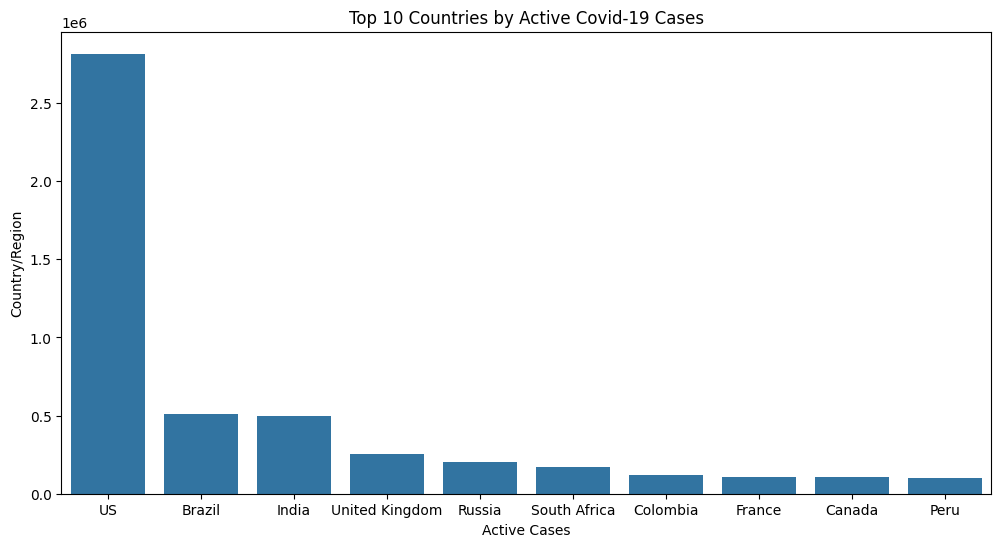

In [24]:
country_stats = data.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False)

print("--- Top 10 Countries by Confirmed Cases ---")
country_stats.head(10)

data['Death_Rate (%)'] = (data['Deaths'] / data['Confirmed']) * 100
data['Recovery_Rate (%)'] = (data['Recovered'] / data['Confirmed']) * 100

print("\n--- Summary Statistics for Global Rates ---")
data[['Death_Rate (%)', 'Recovery_Rate (%)']].describe()

top_10_active = data.sort_values(by='Active', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Country/Region', y='Active', data=top_10_active)
plt.title('Top 10 Countries by Active Covid-19 Cases')
plt.xlabel('Active Cases')
plt.ylabel('Country/Region')
plt.show()

### ***Trend Analysis***

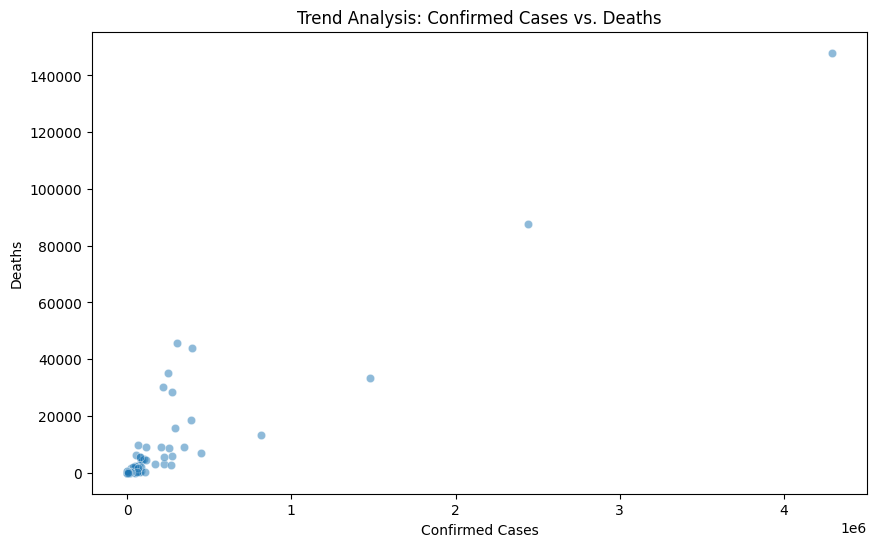

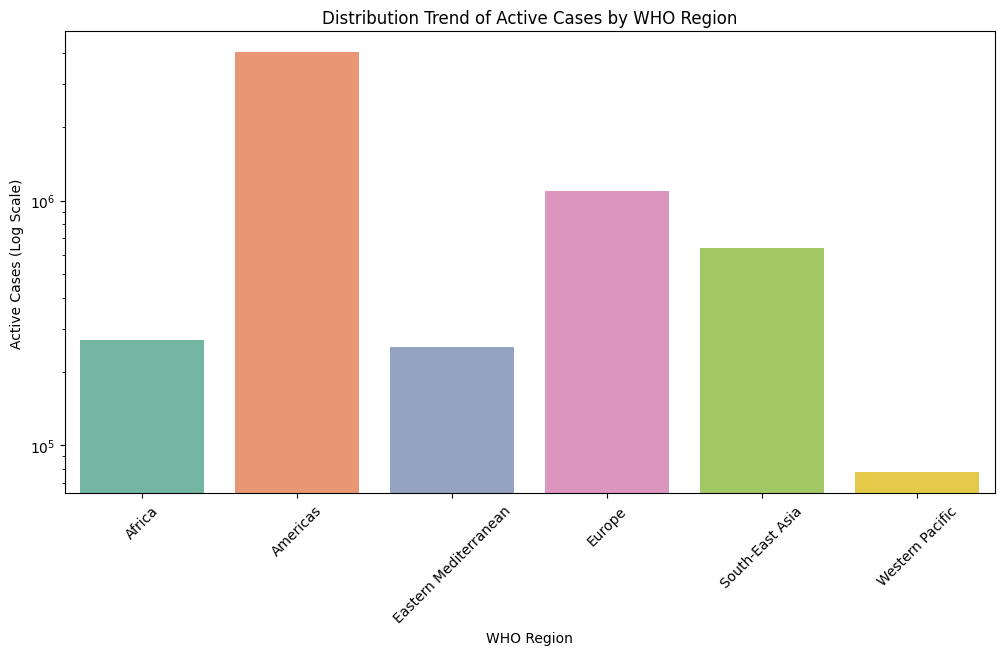

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Confirmed', y='Deaths', data=data, alpha=0.5)
plt.title('Trend Analysis: Confirmed Cases vs. Deaths')
plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')
plt.show()

region_active_data = data.groupby('WHO Region')['Active'].sum().reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='WHO Region', y='Active', data=region_active_data, palette='Set2', hue='WHO Region', dodge=False)
plt.yscale('log')
plt.title('Distribution Trend of Active Cases by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Active Cases (Log Scale)')
plt.xticks(rotation=45)
plt.show()

### ***Heat Maps***

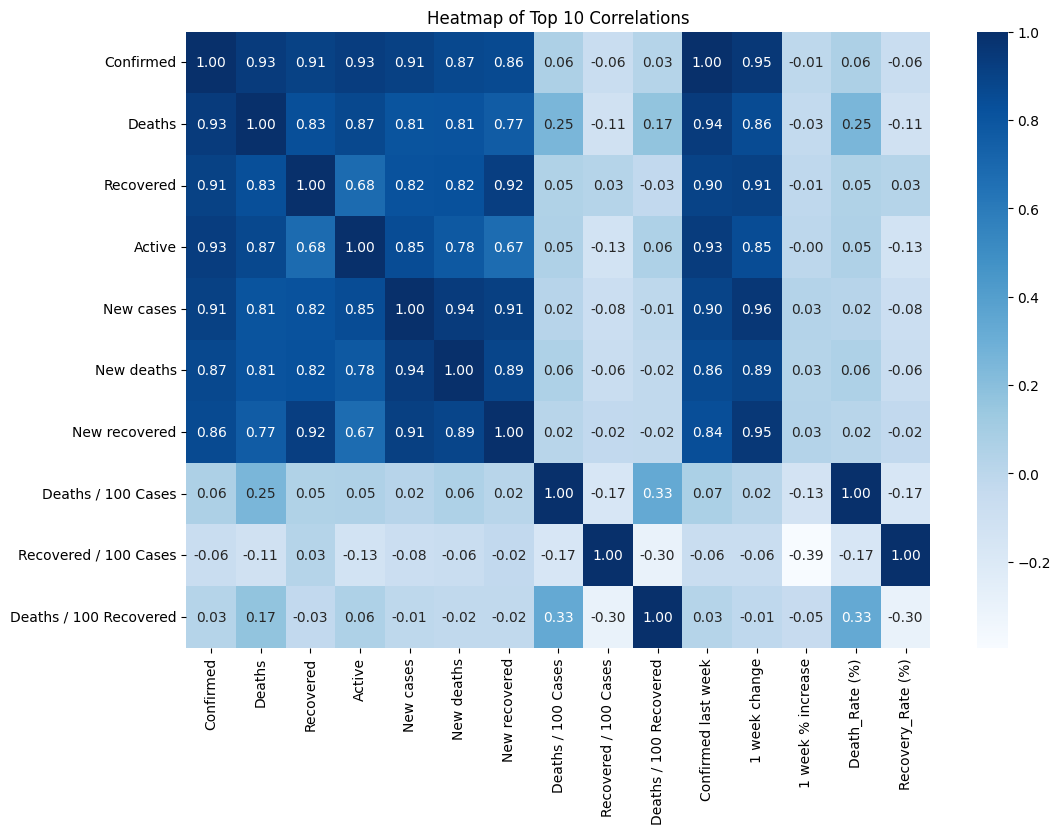

In [40]:
plt.figure(figsize=(12, 8))
correlation_matrix = data.corr(numeric_only=True)
sns.heatmap(correlation_matrix.head(10), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap of Top 10 Correlations')
plt.show()